# Function 5

<b> Description of the Sample Application:</b> You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods



In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [83]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['y'] = y
print("Data Frame:\n", df)


Input  Shape: (20, 4)
Inputs:
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]]

Output Shape: (20,)
Outputs

# Data Exploration

In [86]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            y
count  20.000000  20.000000  20.000000  20.000000    20.000000
mean    0.460387   0.498557   0.477944   0.494719   151.271876
std     0.227206   0.273619   0.246797   0.308458   251.955640
min     0.119879   0.038193   0.088947   0.072880     0.112940
25%     0.286214   0.286061   0.308915   0.180712    22.892661
50%     0.451188   0.535355   0.451095   0.458093    63.948431
75%     0.678976   0.740559   0.657973   0.792954   140.484809
max     0.836478   0.862540   0.879484   0.957644  1088.859618


In [88]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
y      0
dtype: int64


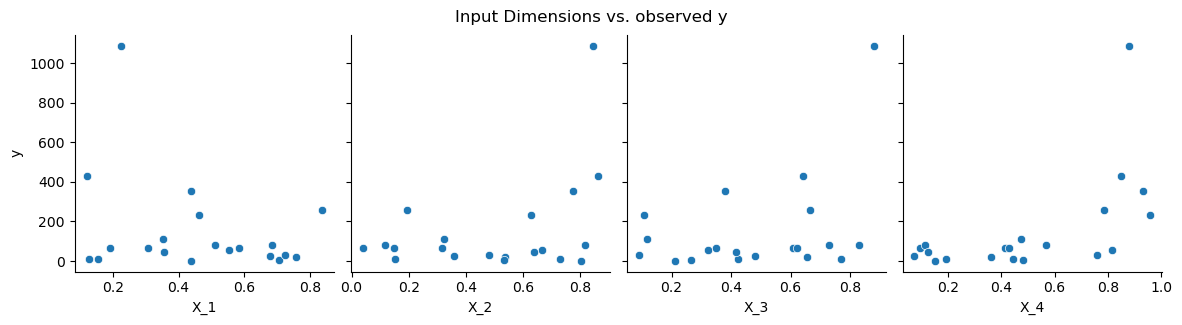

In [90]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed y", y = 1.05)
plt.show()

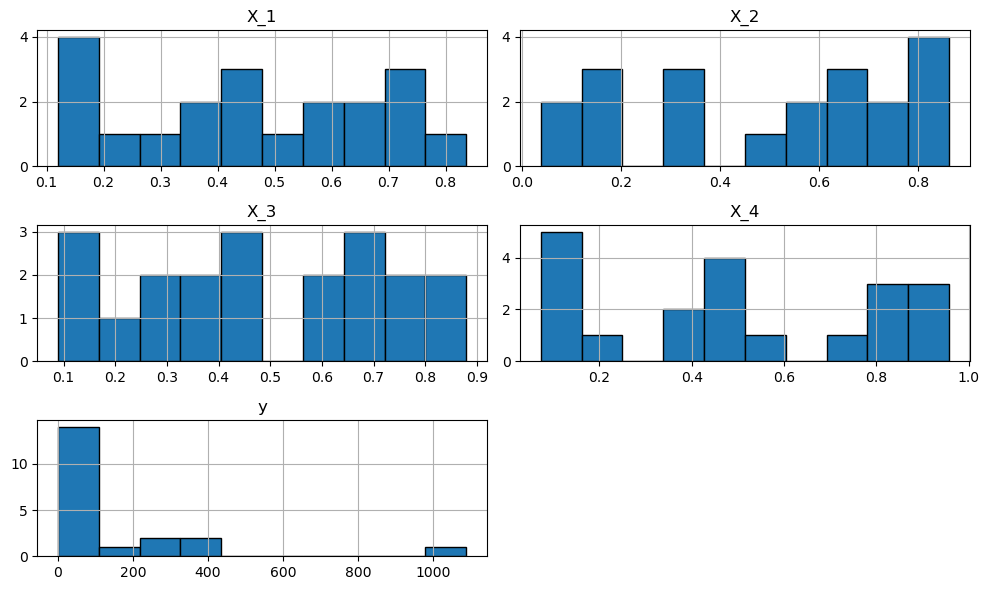

In [91]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [92]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each input with y:

 corr(X_1, y) = -0.2843559747332872
 corr(X_2, y) = 0.3893399436221865
 corr(X_3, y) = 0.36730382540235507
 corr(X_4, y) = 0.5698770759854206


<Axes: >

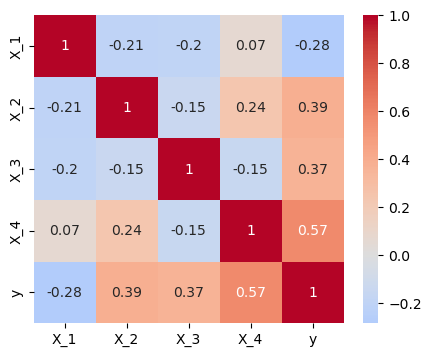

In [94]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

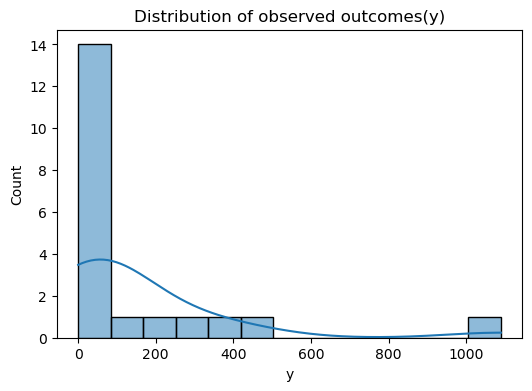

In [95]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['y'], kde = True)
plt.title("Distribution of observed outcomes(y)")
plt.show()

# Initialize Gaussian Process

In [99]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0]*4, length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [104]:
# y is spread beyond 1000, If we model with raw values of y, couple of large values dominate the Gaussian Processes' length-scale/variance fit
# Hence, modelling  log1p(y) rather than raw y. Working in log-space keeps the regression well-conditioned

X_scaler       = StandardScaler()
X_s            = X_scaler.fit_transform(X)

y_log          = np.log1p(y)
y_mean, y_std  = y_log.mean(), y_log.std()
y_s            = (y_log - y_mean) / y_std

# Train the model

gpr.fit(X_s, y_s)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.74**2 * RBF(length_scale=[8.4, 1.58, 4.58, 1.85]) + WhiteKernel(noise_level=1e-05)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [108]:
# Function to predict mean and std for raw x
def predict_yield(X_raw):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    mu_log      = mu_s * y_std + y_mean
    std_log     = std_s * y_std
    mu_yield    = np.expm1(mu_log)
    return mu_yield, std_log

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculare UCB 
def ucb_log_space(X_raw, beta = beta):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    return mu_s + beta * std_s

n_candidates = 200000
RNG          = np.random.default_rng(42)
candidates   = RNG.uniform(0, 1, size = (n_candidates, 4))

ucb_scores   = ucb_log_space(candidates)
next_idx     = np.argmax(ucb_scores)
x_next       = candidates[next_idx]

pred_mu, pred_std_log = predict_yield(x_next.reshape(1, -1))

print(f"Suggested next Query Point: {x_next}")
print(f"Predicted Mean(μ): {pred_mu[0]:.6e}")
print(f"Predicted Std (σ): {pred_std_log[0]:.6e}")
print(f"UCB Score: {ucb_scores[next_idx]:.6e}")

Suggested next Query Point: [0.03743929 0.01423558 0.07068926 0.98630359]
Predicted Mean(μ): 3.464755e+03
Predicted Std (σ): 2.345896e+00
UCB Score: 6.309490e+00


# Perform Visualisation

Full 4D UCB surface can't be drawn directly. Hence, we visualise 2D slices for every pair of dimensions, fix the other two dimensions at the current
best-known x, and sweep a grid over the chosen pair. This shows how UCB (and mu, sigma) behave locally around the best point found so far.

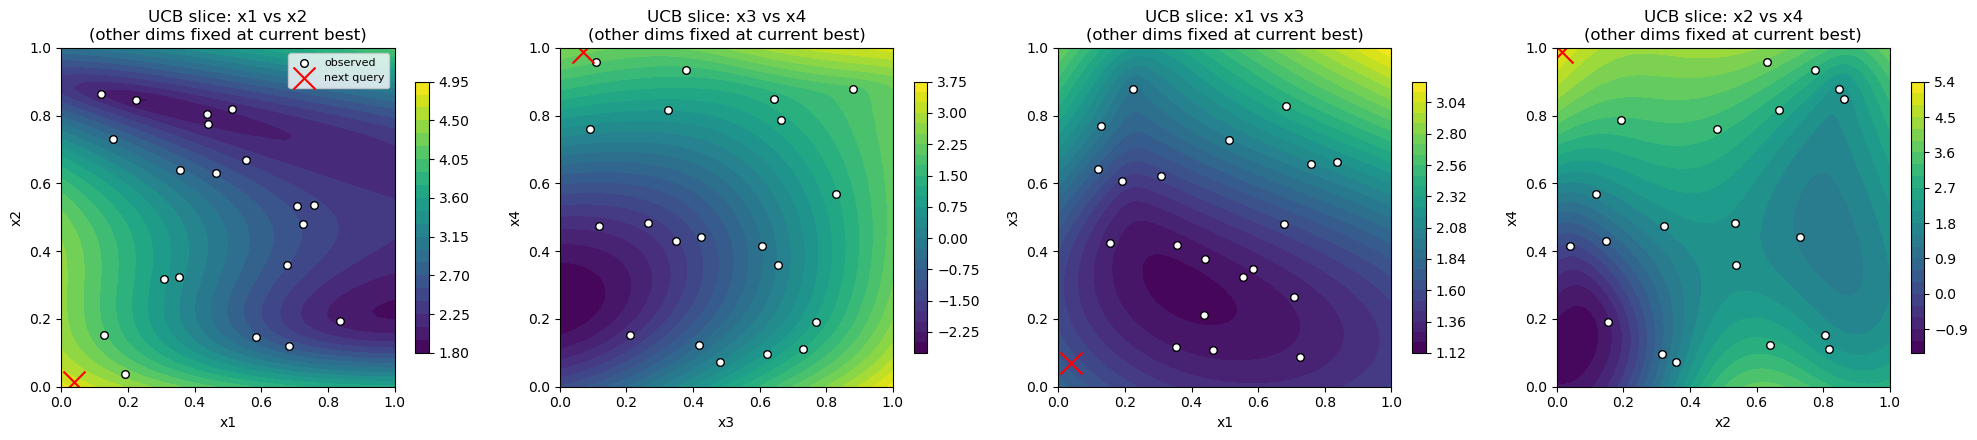

In [112]:
grid_n = 60
grid_1d = np.linspace(0, 1, grid_n)
pairs = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point = X[best_idx].copy()  # anchor the other two dims here
 
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    A, B = np.meshgrid(grid_1d, grid_1d)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()
 
    scores = ucb_log_space(grid_points).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels=25, cmap="viridis")
    ax.scatter(X[:, d1], X[:, d2], c="white", edgecolor="black", s=30, label="observed")
    ax.scatter(x_next[d1], x_next[d2], c="red", marker="x", s=250, label="next query")
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice: x{d1+1} vs x{d2+1}\n(other dims fixed at current best)")
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

# Portal Submission 

In [119]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(x_next)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.037439-0.014236-0.070689-0.986304
